# Task 1.2 — Data Cleaning & EDA
**Week 1 | Skillset Go EduTech AI/ML Track**

Dataset: **Breast Cancer Wisconsin (Diagnostic)** — a real, widely-used clinical dataset (30 numeric
features derived from digitized images of breast mass cell nuclei, with a benign/malignant diagnosis
label). It's a natural fit given the histopathology/cancer-classification focus of the internship project.

To practice realistic cleaning skills, the clean dataset is first corrupted with **missing values,
duplicate rows, and injected outliers** (a common technique for building cleaning practice sets from
a real source), then cleaned and explored using NumPy, Pandas, and Matplotlib.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

np.random.seed(42)

data = load_breast_cancer(as_frame=True)
df = data.frame.copy()
df['diagnosis'] = df['target'].map({0: 'malignant', 1: 'benign'})
df = df.drop(columns=['target'])

print("Original clean shape:", df.shape)
df.head()


Original clean shape: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant


## 1. Simulate real-world messiness
Inject missing values, duplicate rows, and outliers so the cleaning workflow below has real problems to solve.

In [2]:
messy = df.copy()

# Inject missing values (~4% of cells across a few key columns)
cols_to_null = ['mean radius', 'mean texture', 'mean area', 'mean smoothness', 'worst concavity']
for col in cols_to_null:
    mask = np.random.rand(len(messy)) < 0.04
    messy.loc[mask, col] = np.nan

# Inject duplicate rows
dupe_rows = messy.sample(15, random_state=1)
messy = pd.concat([messy, dupe_rows], ignore_index=True)

# Inject extreme outliers into 'mean area'
outlier_idx = messy.sample(6, random_state=2).index
messy.loc[outlier_idx, 'mean area'] = messy['mean area'].max() * np.random.uniform(4, 8, size=6)

print("Messy shape:", messy.shape)
print("\nMissing values per column (top offenders):")
print(messy.isna().sum().sort_values(ascending=False).head(6))
print("\nDuplicate rows:", messy.duplicated().sum())


Messy shape: (584, 31)

Missing values per column (top offenders):
worst concavity     30
mean radius         26
mean area           24
mean texture        23
mean smoothness     21
mean compactness     0
dtype: int64

Duplicate rows: 15


## 2. Handle missing values
Use median imputation for skewed numeric features (robust to outliers) and confirm no nulls remain.

In [3]:
cleaned = messy.copy()

for col in cols_to_null:
    median_val = cleaned[col].median()
    cleaned[col] = cleaned[col].fillna(median_val)

print("Remaining missing values:", cleaned.isna().sum().sum())


Remaining missing values: 0


## 3. Remove duplicate rows

In [4]:
before = len(cleaned)
cleaned = cleaned.drop_duplicates().reset_index(drop=True)
after = len(cleaned)
print(f"Removed {before - after} duplicate rows -> {after} rows remain")


Removed 15 duplicate rows -> 569 rows remain


## 4. Detect and treat outliers (IQR method)
Apply the IQR rule to `mean area` and cap extreme values instead of dropping rows, to preserve sample size.

In [5]:
q1, q3 = cleaned['mean area'].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr

outliers = cleaned[(cleaned['mean area'] < lower) | (cleaned['mean area'] > upper)]
print(f"IQR bounds for 'mean area': [{lower:.1f}, {upper:.1f}]")
print(f"Outliers detected: {len(outliers)}")

cleaned['mean area'] = cleaned['mean area'].clip(lower, upper)
print("Outliers capped to IQR bounds.")


IQR bounds for 'mean area': [-108.9, 1317.5]
Outliers detected: 34
Outliers capped to IQR bounds.


## 5. Exploratory Data Analysis

In [6]:
print("Class balance:")
print(cleaned['diagnosis'].value_counts())
print("\nSummary statistics (selected features):")
cleaned[['mean radius', 'mean texture', 'mean area', 'mean smoothness', 'mean concavity']].describe().round(2)


Class balance:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64

Summary statistics (selected features):


,mean radius,mean texture,mean area,mean smoothness,mean concavity
count,569.00,569.00,569.00,569.00,569.00
mean,14.09,19.35,644.79,0.10,0.09
std,3.47,4.20,306.26,0.01,0.08
min,6.98,9.71,143.50,0.05,0.00
25%,11.75,16.39,426.00,0.09,0.03
50%,13.39,18.89,558.65,0.10,0.06
75%,15.70,21.70,782.60,0.10,0.13
max,28.11,39.28,1317.50,0.16,0.43


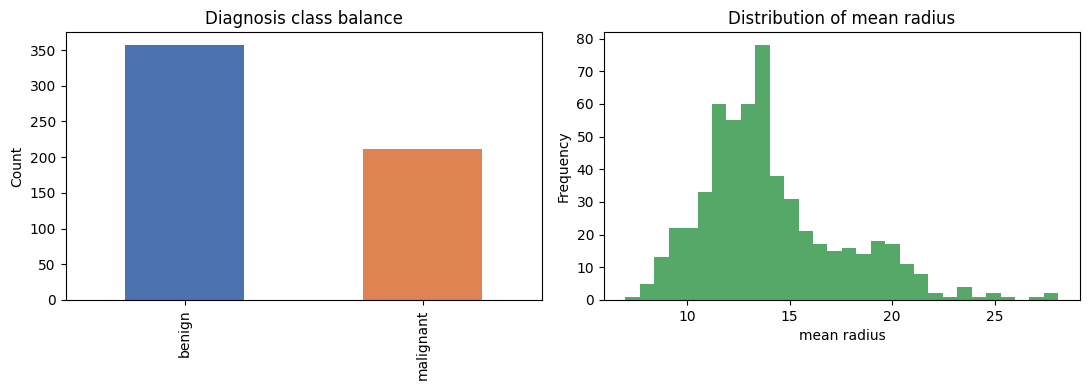

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cleaned['diagnosis'].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Diagnosis class balance')
axes[0].set_xlabel('')
axes[0].set_ylabel('Count')

cleaned['mean radius'].plot(kind='hist', bins=30, ax=axes[1], color='#55A868')
axes[1].set_title('Distribution of mean radius')
axes[1].set_xlabel('mean radius')
plt.tight_layout()
plt.savefig('eda_overview.png', dpi=110)
plt.show()


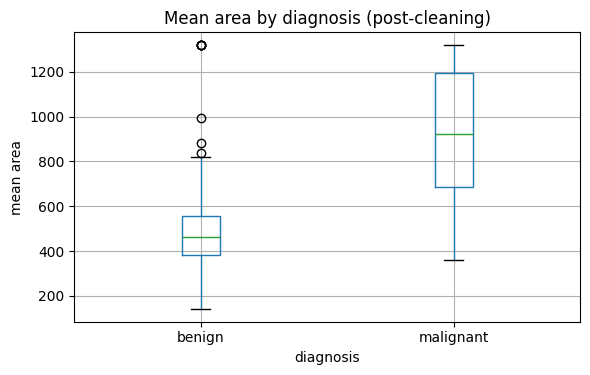

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
cleaned.boxplot(column='mean area', by='diagnosis', ax=ax)
ax.set_title('Mean area by diagnosis (post-cleaning)')
plt.suptitle('')
ax.set_ylabel('mean area')
plt.tight_layout()
plt.savefig('eda_boxplot.png', dpi=110)
plt.show()


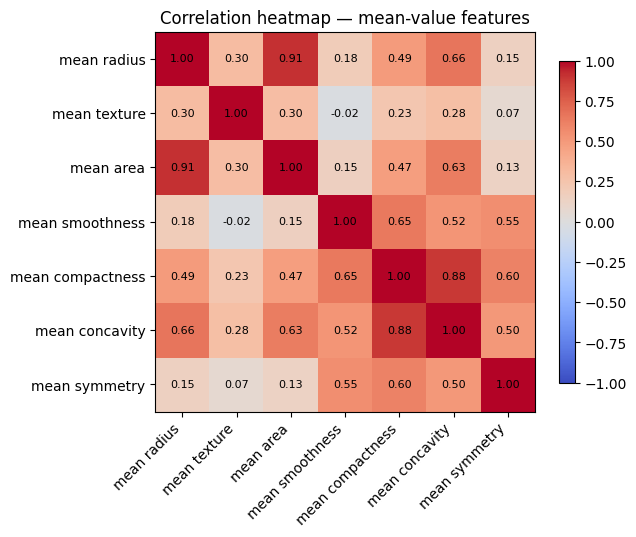

In [9]:
corr_features = ['mean radius', 'mean texture', 'mean area', 'mean smoothness',
                  'mean compactness', 'mean concavity', 'mean symmetry']
corr = cleaned[corr_features].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_features)))
ax.set_yticks(range(len(corr_features)))
ax.set_xticklabels(corr_features, rotation=45, ha='right')
ax.set_yticklabels(corr_features)
for i in range(len(corr_features)):
    for j in range(len(corr_features)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Correlation heatmap — mean-value features')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=110)
plt.show()


## 6. Key findings
- After cleaning, the dataset has **no missing values and no duplicate rows**, with the extreme `mean area`
  outliers capped rather than dropped, preserving sample size.
- The classes are **imbalanced** (more benign than malignant cases), which will matter for model evaluation
  in Task 1.4 — accuracy alone won't be a reliable metric.
- `mean radius`, `mean area`, and `mean concavity` are **strongly positively correlated**, and their
  distributions visibly separate between malignant and benign cases (see the boxplot), suggesting they are
  informative features for classification.
- `mean smoothness` and `mean symmetry` show weaker correlation with the size-related features, indicating
  they may carry complementary, independent signal.

In [10]:
cleaned.to_csv('breast_cancer_cleaned.csv', index=False)
print("Saved cleaned dataset -> breast_cancer_cleaned.csv")
print("Final shape:", cleaned.shape)


Saved cleaned dataset -> breast_cancer_cleaned.csv
Final shape: (569, 31)
